In [7]:
import pandas as pd
from neuralforecast import NeuralForecast
import sys
import os
sys.path.append(os.path.abspath("../../"))
from QNeuralForecast.dlinear import QDLinear
from neuralforecast.models import DLinear, NHITS, PatchTST, TimesNet

from pytorch_lightning.loggers import TensorBoardLogger

In [8]:
df = pd.read_csv("../data/train_prepared.csv", parse_dates=["Date"], low_memory=False)

df = df.sort_values(["Store","Date"])

split_date = "2015-01-01"

train_df = df[df["Date"] < split_date].copy()
val_df   = df[df["Date"] >= split_date].copy()

In [17]:
HORIZON=210
INPUT_SIZE=500
#OPTIMIZER=Adam() # <-- TODO: specify list of params
MAX_STEPS=300
SCALER_TYPE="standard"
dlinear = DLinear(
    h=HORIZON,
    input_size=INPUT_SIZE,
    max_steps=MAX_STEPS,
    scaler_type=SCALER_TYPE,
    **{"logger":TensorBoardLogger("lightning_logs", name="DLinear")},
    #optimizer=OPTIMIZER
)
qdlinear = QDLinear(
    h=HORIZON,
    input_size=INPUT_SIZE,
    max_steps=MAX_STEPS,
    scaler_type=SCALER_TYPE,
    **{"logger":TensorBoardLogger("lightning_logs", name="QDLinear")},
    #optimizer=OPTIMIZER
)
nhits = NHITS(
    h=HORIZON,
    input_size=INPUT_SIZE,
    max_steps=MAX_STEPS,
    scaler_type=SCALER_TYPE,
    **{"logger":TensorBoardLogger("lightning_logs", name="NHITS")},
    #optimizer=OPTIMIZER,
)
patchtst = PatchTST(
    h=HORIZON,
    input_size=INPUT_SIZE,
    max_steps=MAX_STEPS,
    scaler_type=SCALER_TYPE,
    **{"logger":TensorBoardLogger("lightning_logs", name="PatchTST")},
    #optimizer=OPTIMIZER,
)
timesnet = TimesNet(
    h=HORIZON,
    input_size=INPUT_SIZE,
    max_steps=MAX_STEPS,
    scaler_type=SCALER_TYPE,
    **{"logger":TensorBoardLogger("lightning_logs", name="TimesNet")},
    #optimizer=OPTIMIZER,
)

Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1


In [18]:
nf = NeuralForecast(models=[qdlinear,dlinear,nhits,patchtst,timesnet], freq="D")
nf = NeuralForecast(models=[qdlinear,dlinear,nhits,patchtst], freq="D")

In [14]:
nf = NeuralForecast(models=[qdlinear], freq="D")

In [19]:
nf.fit(train_df,
       id_col="Store",
       time_col="Date",
       target_col="Sales",
       verbose=True,
       distributed_config=None)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MAE               │      0 │ train │     0 │
│ 1 │ padder_train  │ ConstantPad1d     │      0 │ train │     0 │
│ 2 │ scaler        │ TemporalNorm      │      0 │ train │     0 │
│ 3 │ decomp        │ SeriesDecomp      │      0 │ train │     0 │
│ 4 │ linear_trend  │ QuantumProjection │  3.1 K │ train │     0 │
│ 5 │ linear_season │ QuantumProjection │  3.1 K │ train │     0 │
└───┴───────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 6.1 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 6.1 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_steps=300` reached.


...

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE               │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d     │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm      │      0 │ train │     0 │
│ 3 │ model        │ PatchTST_backbone │  2.1 M │ train │     0 │
└───┴──────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 2.1 M                                                                                            
Non-trainable params: 3                                                                                            
Total params: 2.1 M                                                                                                
Total estimated model params size (MB): 8                                                                          
Modules in train mode: 90                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_steps=300` reached.


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

Models found: ['QDLinear', 'DLinear', 'NHITS', 'PatchTST']

Global MAE per model:
QDLinear: 1589.0839
DLinear: 1677.2288
NHITS: 1893.8468
PatchTST: 2417.4829

Top 5 Stores (Best Predicted on Average): [794, 789, 656, 208, 558]


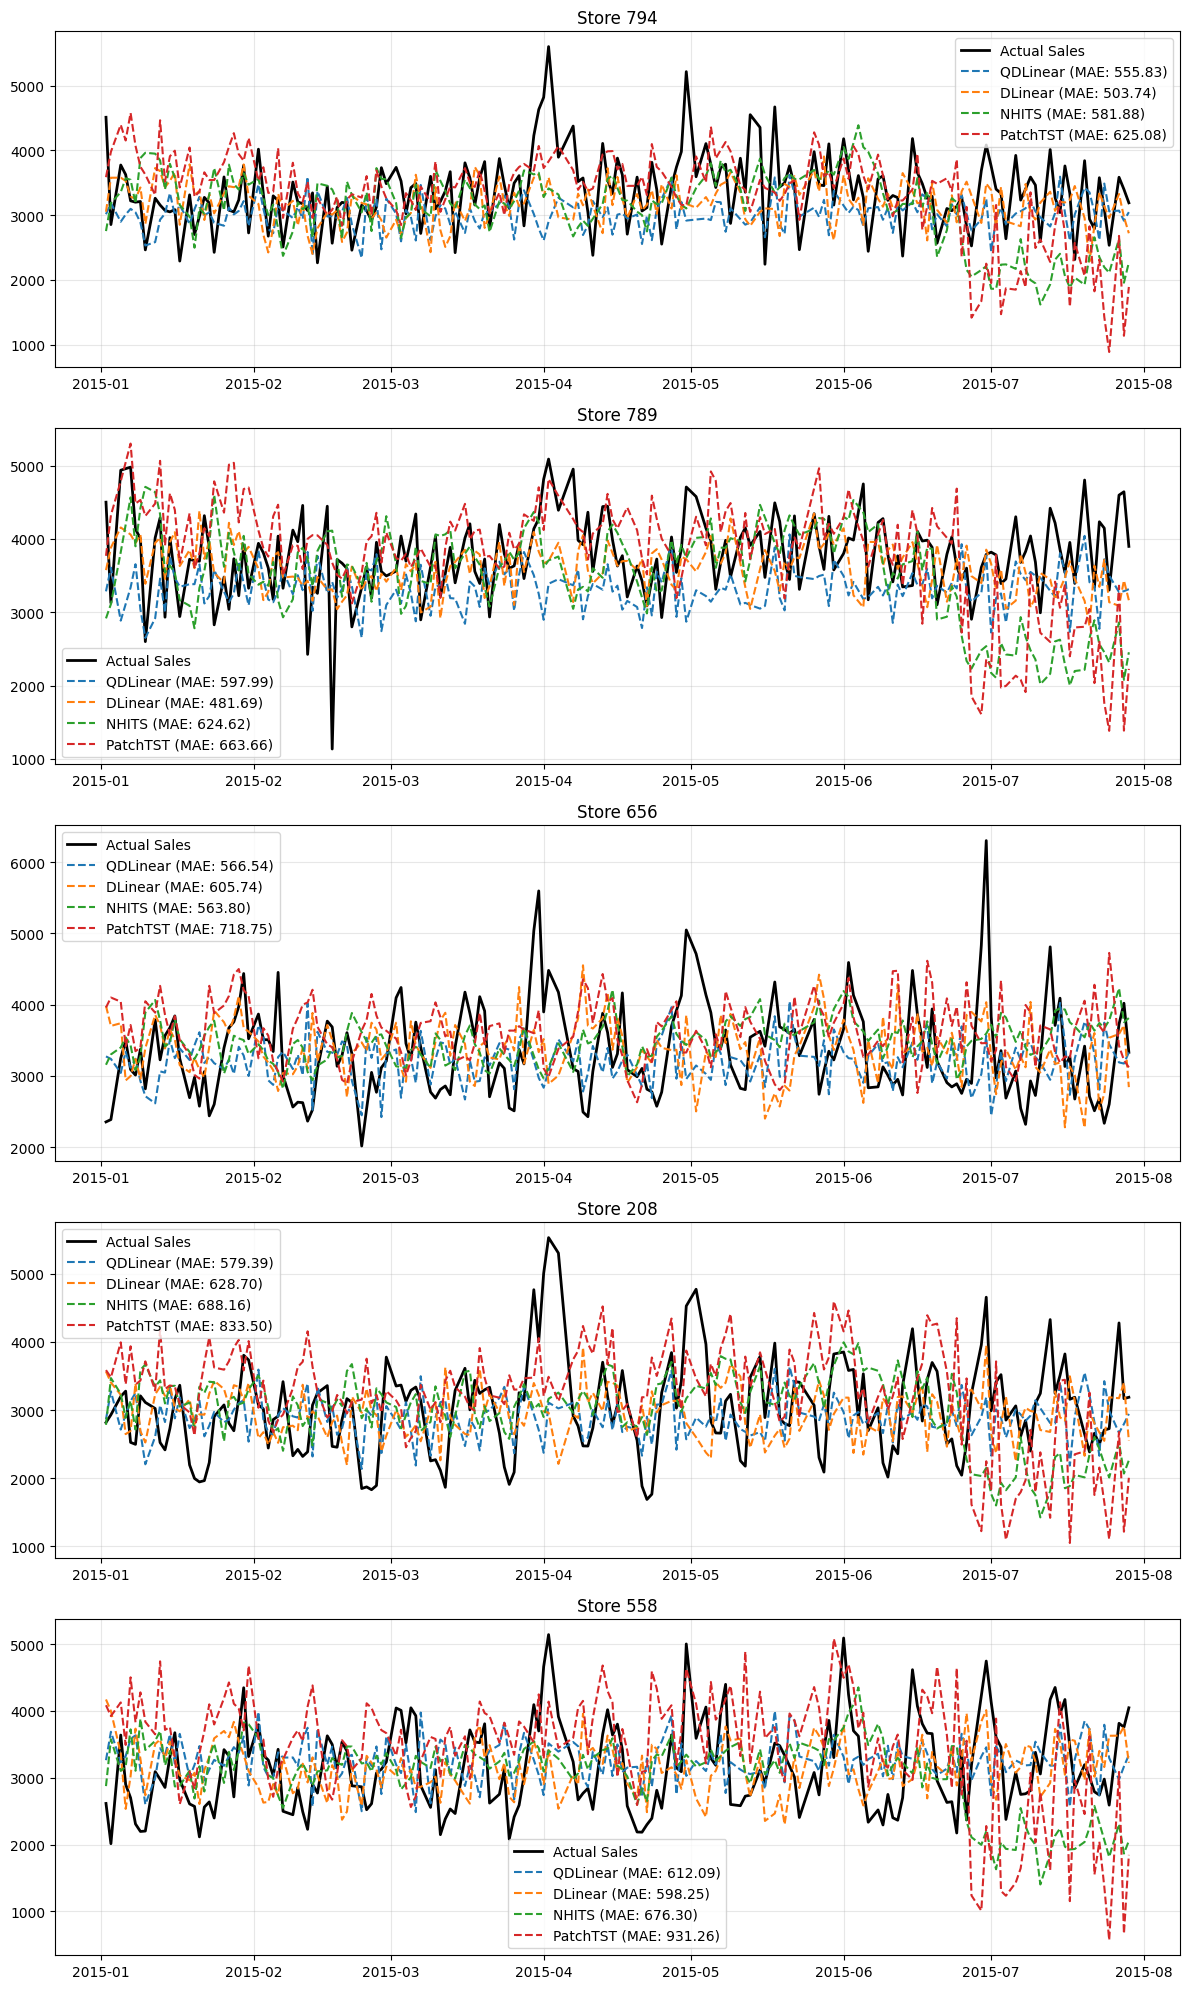

In [20]:
# Predict with all models
forecasts = nf.predict().reset_index()
# Merge with validation values to compare
comparison = val_df[["Store", "Date", "Sales"]].merge(forecasts, on=["Store", "Date"], how="inner")

# Identify the model columns (exclude Store, Date, and Sales if it somehow got in there)
model_names = [col for col in forecasts.columns if col not in ["index","Store", "Date"]]
forecasts.drop(["index"],axis=1)
print(f"Models found: {model_names}")

# Calculate separate MAE for each model
results = {}
for model in model_names:
    mae = (comparison["Sales"] - comparison[model]).abs().mean()
    results[model] = mae

print("\nGlobal MAE per model:")
for m, score in sorted(results.items(), key=lambda x: x[1]):
    print(f"{m}: {score:.4f}")

# Find Top 5 Best Predicted Stores (using average error across all models)
comparison["avg_model_error"] = 0
for model in model_names:
    comparison["avg_model_error"] += (comparison["Sales"] - comparison[model]).abs()
comparison["avg_model_error"] /= len(model_names)

mae_per_store = comparison.groupby("Store")["avg_model_error"].mean().sort_values()
top_5_stores = mae_per_store.head(5).index.tolist()

print(f"\nTop 5 Stores (Best Predicted on Average): {top_5_stores}")

import matplotlib.pyplot as plt

# Plot for the top 5 stores
fig, axes = plt.subplots(5, 1, figsize=(12, 20), sharex=False)

for i, store_id in enumerate(top_5_stores):
    store_data = comparison[comparison["Store"] == store_id]
    
    ax = axes[i]
    # Plot Actual
    ax.plot(store_data["Date"], store_data["Sales"], label="Actual Sales", color='black', linewidth=2)
    
    # Plot each model
    for model in model_names:
        model_mae = (store_data["Sales"] - store_data[model]).abs().mean()
        ax.plot(store_data["Date"], store_data[model], label=f"{model} (MAE: {model_mae:.2f})", linestyle='--')
    
    ax.set_title(f"Store {store_id}")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()